# Identify theta sweeps

A **theta sweep** is the systematic progression of the *decoded* position across a single
theta cycle: early in the cycle the decode sits behind / at the animal, and late in the cycle
it sweeps ahead. We quantify this per theta cycle with a simple **late − early contrast** of
`decode_distance` (cm, + = ahead of the rat):

    sweep_score = mean(decode_distance in late half)  −  mean(decode_distance in early half)

Positive score = the decode is further ahead late in the cycle = a forward sweep.

Theta cycles are segmented using the **saved reference-electrode phase**
(`HexMazeThetaReference`), the same reference used elsewhere in the pipeline. Phase runs
0 = peak → 180 = trough → 360 = peak; we call 0–180° the *early* half and 180–360° the *late* half.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from spyglass_hexmaze.hex_maze_decoding import HexMazeDecodedPosition, HexMazeThetaReference

# ----------------------------- config -----------------------------
nwb_file_name = "IM-1478_20220720_.nwb"
REFERENCE_NAME = "theta_reference_1"     # saved reference set to segment theta cycles by

# Which samples are trustworthy for a sweep measurement
RUN_SPEED = 5.0          # cm/s: only look at running times (sweeps are a running-theta phenomenon)
SPATIAL_COV_MAX = 200.0  # only keep confident decodes (drop high spatial-coverage / uncertain samples)

# Early vs late halves of the theta cycle (deg; 0 = peak, 180 = trough, 360 = peak)
EARLY_BAND = (0, 180)
LATE_BAND = (180, 360)

# A cycle is only scored if it has at least this many kept samples in EACH half
MIN_SAMPLES_PER_HALF = 2

# |decode_distance| >= FAR_THRESH counts as "far" / nonlocal (used to classify each sweep's
# locality: always-near, always-far, or near<->far). "distance from rat" is signed (+ahead).
FAR_THRESH = 50.0        # cm

session_id = nwb_file_name.replace("_.nwb", "")
key = {"nwb_file_name": nwb_file_name}

# Save figures as PDFs, one folder per session (same convention as the rest of the project)
FIG_DIR = Path("figures") / session_id
FIG_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(fig, name):
    """Save a figure as a PDF into FIG_DIR."""
    path = FIG_DIR / f"{name}.pdf"
    fig.savefig(path, bbox_inches="tight")
    print(f"saved {path}")

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-07-02 15:38:34,321][INFO]: DataJoint 0.14.6 connected to scrater@lmf-db.cin.ucsf.edu:3306
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core 

4841 sign-flip jumps (|dist| > 20.0 cm on both sides)
median |aheadness| at the flip: 0.054  (near 0 == decode is lateral, i.e. the artifact)


,time,dist_before,dist_after,aheadness_before,aheadness_after
0,19.574026,-62.770741,62.834496,-0.269270,0.971893
1,19.576026,62.834496,-62.866384,0.971893,-0.684972
2,19.796026,-70.100778,70.128875,-0.597886,0.992855
3,19.798026,70.128875,-70.185196,0.992855,-0.388766
4,20.330026,-20.273108,20.312944,-0.854775,0.874310
5,20.332026,20.312944,-20.332906,0.874310,-0.014193
6,31.214026,-93.168091,93.071401,-0.004321,0.006405
7,32.942026,56.683624,-54.813067,0.041206,-0.032625
8,36.574026,-84.694002,84.541509,-0.007644,0.003864
9,37.786026,37.033995,-37.101189,0.019489,-0.000803


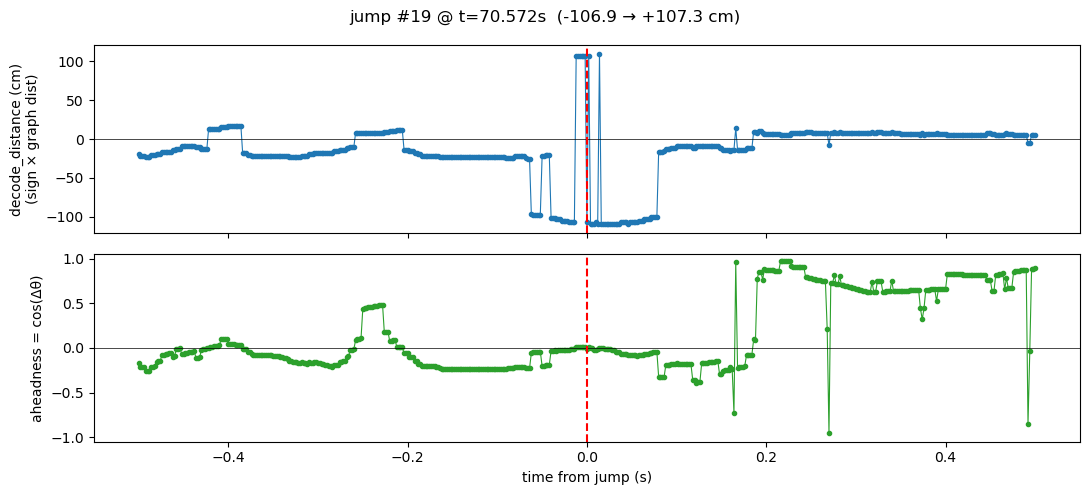

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from spyglass_hexmaze.hex_maze_decoding import HexMazeDecodedPosition, compute_aheadness

nwb_file_name = "IM-1478_20220720_.nwb"
key = {"nwb_file_name": nwb_file_name}

# --- 1. Fetch one decode and compute raw aheadness = cos(Δθ) ---
df = (HexMazeDecodedPosition & key).fetch1_dataframe()   # indexed by time
df["aheadness"] = compute_aheadness(df)

# --- 2. Find the "jumps": consecutive samples where decode_distance flips sign
#        while staying large in magnitude. A REAL sweep crosses zero smoothly
#        (small |value| on both sides), so requiring both sides to be large
#        isolates the artifact flips (e.g. +50 -> -50) and ignores clean sweeps. ---
MAG_THRESH = 20.0   # cm; both sides of the flip must exceed this to count as a jump

d = df["decode_distance"].to_numpy()
prev, curr = d[:-1], d[1:]
sign_flip = np.sign(prev) != np.sign(curr)
both_large = np.minimum(np.abs(prev), np.abs(curr)) > MAG_THRESH
jump_idx = np.where(sign_flip & both_large)[0]   # index i = flip between i and i+1

# --- 3. Table of every jump with the aheadness right around it ---
ahead = df["aheadness"].to_numpy()
jumps = pd.DataFrame({
    "time":            df.index[jump_idx],
    "dist_before":     d[jump_idx],
    "dist_after":      d[jump_idx + 1],
    "aheadness_before": ahead[jump_idx],
    "aheadness_after":  ahead[jump_idx + 1],
})
print(f"{len(jumps)} sign-flip jumps (|dist| > {MAG_THRESH} cm on both sides)")
print(f"median |aheadness| at the flip: "
      f"{np.nanmedian(np.abs(jumps[['aheadness_before','aheadness_after']].values)):.3f}  "
      f"(near 0 == decode is lateral, i.e. the artifact)")
display(jumps.head(20))

# --- 4. Eyeball one jump: decode_distance and aheadness in a window around it ---
def plot_jump(n=0, pad=0.5):
    """Plot decode_distance (top) and aheadness (bottom) in a ±pad-second window
    around the n-th detected jump."""
    t = df.index[jump_idx[n]]
    w = df.loc[t - pad : t + pad]

    fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    ax[0].plot(w.index - t, w["decode_distance"], ".-", lw=0.8)
    ax[0].axhline(0, color="k", lw=0.5); ax[0].axvline(0, color="r", ls="--")
    ax[0].set_ylabel("decode_distance (cm)\n(sign × graph dist)")

    ax[1].plot(w.index - t, w["aheadness"], ".-", lw=0.8, color="tab:green")
    ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(0, color="r", ls="--")
    ax[1].set_ylabel("aheadness = cos(Δθ)"); ax[1].set_ylim(-1.05, 1.05)
    ax[1].set_xlabel("time from jump (s)")
    fig.suptitle(f"jump #{n} @ t={t:.3f}s  ({d[jump_idx[n]]:+.1f} → {d[jump_idx[n]+1]:+.1f} cm)")
    plt.tight_layout(); plt.show()

plot_jump(19)   # step through: plot_jump(1), plot_jump(2), ...


In [12]:
# Classify each jump by how far the cosine swings — small = lateral artifact,
# large = decode direction genuinely flipping (bimodal MAP hopping)
jumps["max_abs_ahead"] = jumps[["aheadness_before", "aheadness_after"]].abs().max(axis=1)

LATERAL_CUT = 0.2   # |cos| below this on both sides == decode is ~perpendicular
type_B = jumps["max_abs_ahead"] < LATERAL_CUT     # lateral artifact  -> deadband fixes
type_A = ~type_B                                   # far bimodal flip  -> deadband won't

print(f"Type B (lateral, cos~0):   {type_B.sum():3d}  -> a cos deadband suppresses these")
print(f"Type A (far, cos flips):   {type_A.sum():3d}  -> needs temporal/confidence gating")

# Do the Type A flips coincide with low decode confidence (wide posterior)?
# spatial_cov = fraction of the maze in the 95% HPD region; higher = less certain.
cov = df["spatial_cov"].to_numpy()
for label, mask in [("Type A", type_A), ("Type B", type_B)]:
    idx = jump_idx[mask.to_numpy()]
    print(f"{label}: median spatial_cov at flip = {np.nanmedian(cov[idx]):.3f}")

# Time clustering: are the Type A flips bursts of consecutive samples?
print("\nType A jump times:", np.round(jumps.loc[type_A, "time"].to_numpy(), 3))


Type B (lateral, cos~0):   2736  -> a cos deadband suppresses these
Type A (far, cos flips):   2105  -> needs temporal/confidence gating
Type A: median spatial_cov at flip = 414.000
Type B: median spatial_cov at flip = 204.000

Type A jump times: [  19.574   19.576   19.796 ... 6771.878 6774.816 6774.828]


In [15]:
def find_sign_flip_jumps(df, mag_thresh=20.0, require_adjacent=True):
    """Flips of decode_distance that stay large on both sides (artifact flips, not
    smooth zero-crossings), with aheadness on each side. require_adjacent skips
    flips that span a time gap left by filtering."""
    d = df["decode_distance"].to_numpy()
    ahead = compute_aheadness(df).to_numpy()
    t = df.index.to_numpy()

    prev, curr = d[:-1], d[1:]
    keep = (np.sign(prev) != np.sign(curr)) & (np.minimum(np.abs(prev), np.abs(curr)) > mag_thresh)
    if require_adjacent:
        keep &= np.diff(t) < 1.5 * np.median(np.diff(t))   # only consecutive samples

    idx = np.where(keep)[0]
    out = pd.DataFrame({
        "time": t[idx],
        "dist_before": d[idx],      "dist_after": d[idx + 1],
        "aheadness_before": ahead[idx], "aheadness_after": ahead[idx + 1],
    })
    out["max_abs_ahead"] = out[["aheadness_before", "aheadness_after"]].abs().max(axis=1)
    return out, idx

COV_THRESH = 200   # from the histogram; tune

df_conf = df[df["spatial_cov"] <= COV_THRESH].copy()
print(f"kept {len(df_conf)}/{len(df)} samples ({len(df_conf)/len(df):.1%})")

for name, d_ in [("all samples", df), (f"spatial_cov<={COV_THRESH}", df_conf)]:
    j, _ = find_sign_flip_jumps(d_)
    nB = (j["max_abs_ahead"] < 0.2).sum()
    nA = (j["max_abs_ahead"] >= 0.2).sum()
    print(f"{name:>22}: {len(j):5d} jumps  |  Type B(lateral)={nB:5d}  Type A(far)={nA:5d}")


kept 2155451/3384862 samples (63.7%)
           all samples:  4841 jumps  |  Type B(lateral)= 2736  Type A(far)= 2105
      spatial_cov<=200:  1853 jumps  |  Type B(lateral)= 1323  Type A(far)=  530


Type A: median decode step at flip = 0.0 cm/sample
Type B: median decode step at flip = 2.0 cm/sample


<Axes: ylabel='Frequency'>

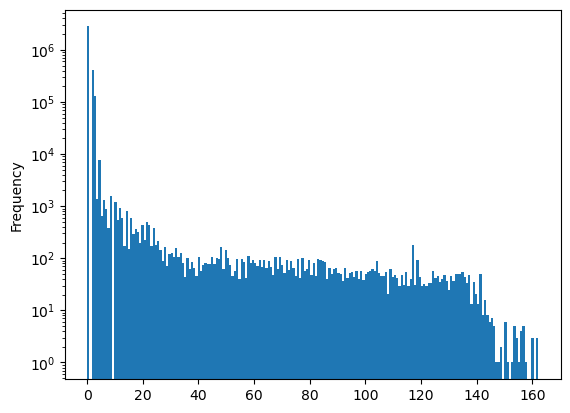

In [17]:
# 1. decode displacement per sample on the FULL, contiguous df (correct adjacency)
df["decode_step"] = np.hypot(df["decode_position_x"].diff(), df["decode_position_y"].diff())

# 2. re-slice df_conf so it carries the new column (use whatever COV_THRESH you chose)
COV_THRESH = 200
df_conf = df[df["spatial_cov"] <= COV_THRESH].copy()

# 3. now the diagnostic works
j_conf, idx_conf = find_sign_flip_jumps(df_conf)
j_conf["decode_step_after"] = df_conf["decode_step"].to_numpy()[idx_conf + 1]
for label, m in [("Type A", j_conf["max_abs_ahead"] >= 0.2),
                 ("Type B", j_conf["max_abs_ahead"] <  0.2)]:
    print(f"{label}: median decode step at flip = {j_conf.loc[m, 'decode_step_after'].median():.1f} cm/sample")

df["decode_step"].plot.hist(bins=200, log=True)


In [18]:
# decode is frozen at Type A flips, so the sign must come from the rat's orientation.
# A ~180° orientation jump = head-direction tracking flip. (find_sign_flip_jumps used
# require_adjacent, so idx and idx+1 are truly consecutive — this diff is valid.)
ori = df_conf["orientation"].to_numpy()
dori = np.abs(np.angle(np.exp(1j * (ori[idx_conf + 1] - ori[idx_conf]))))  # wrapped to [0, π]
j_conf["ori_jump_deg"] = np.degrees(dori)

for label, m in [("Type A", j_conf["max_abs_ahead"] >= 0.2),
                 ("Type B", j_conf["max_abs_ahead"] <  0.2)]:
    print(f"{label}: median |orientation jump| at flip = {j_conf.loc[m, 'ori_jump_deg'].median():.1f} deg")


Type A: median |orientation jump| at flip = 119.6 deg
Type B: median |orientation jump| at flip = 0.1 deg


In [ ]:
# per-sample orientation jump (wrapped to [0,180]). >~20°/2ms = >10k°/s = non-physical glitch.
df["ori_jump_deg"] = np.degrees(np.abs(np.angle(np.exp(1j * df["orientation"].diff()))))

ORI_JUMP_MAX = 20
# a glitch flips for one sample then back, so flag a sample if EITHER its incoming or
# outgoing jump is non-physical (marks the glitched sample and its partner edge)
bad_ori = (df["ori_jump_deg"] > ORI_JUMP_MAX) | (df["ori_jump_deg"].shift(-1) > ORI_JUMP_MAX)
print(f"{bad_ori.sum()} samples ({bad_ori.mean():.2%}) flagged as orientation glitches")

# how many of the surviving Type A flips does this catch?
typeA = j_conf["max_abs_ahead"] >= 0.2
caught = (j_conf.loc[typeA, "ori_jump_deg"] > ORI_JUMP_MAX).sum()
print(f"orientation jump > {ORI_JUMP_MAX}° catches {caught}/{typeA.sum()} Type A flips")


4432 samples (0.13%) flagged as orientation glitches
orientation jump > 10° catches 447/530 Type A flips


## Load reference theta phase and the decode, aligned on one time axis

In [7]:
from spyglass_hexmaze.hex_maze_decoding import HexMazeDecodedPosition, HexMazeThetaReference
REFERENCE_NAME = "theta_reference_1" 

# Averaged theta phase from the saved reference electrodes (radians [0, 2pi], time-indexed)
ref = HexMazeThetaReference & {**key, "reference_name": REFERENCE_NAME}
theta_phase = ref.fetch1_reference_phase()              # pd.Series, radians, indexed by time
theta_power = ref.fetch1_reference_power()              # pd.Series, amplitude^2, indexed by time
phase_deg = np.degrees(theta_phase.values) % 360        # 0 = peak, 180 = trough

# Decode distance + the quality/behavior columns, aligned onto the theta-phase time base.
# nearest-reindex matches each theta sample to the closest decode sample (decode is coarser).
decode_df = (HexMazeDecodedPosition & key).fetch1_dataframe()
dist = decode_df["decode_distance"].reindex(theta_phase.index, method="nearest")
speed = decode_df["speed"].reindex(theta_phase.index, method="nearest")
cov = decode_df["spatial_cov"].reindex(theta_phase.index, method="nearest")

# One tidy frame, one row per theta sample
df = pd.DataFrame({
    "phase_deg": phase_deg,
    "power": theta_power.values,
    "dist": dist.values,
    "speed": speed.values,
    "cov": cov.values,
}, index=theta_phase.index)

# Keep only running, confident, non-NaN samples for the sweep measurement
df["keep"] = (df["speed"] >= RUN_SPEED) & (df["cov"] < SPATIAL_COV_MAX) & df["dist"].notna()
print(f"{len(df)} theta samples | {int(df['keep'].sum())} kept (running & confident)")
df.head()

[2026-07-02 16:47:32,456][WARNING]: Skipped checksum for file with hash: a11a4b09-bd10-28f0-3fb1-7caf2efb8cde, and path: /stelmo/nwb/analysis/IM-1478_20220720/IM-1478_20220720_M4B8NY7XMF.nwb
[2026-07-02 16:47:32,467][WARNING]: Skipped checksum for file with hash: a11a4b09-bd10-28f0-3fb1-7caf2efb8cde, and path: /stelmo/nwb/analysis/IM-1478_20220720/IM-1478_20220720_M4B8NY7XMF.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

NameError: name 'RUN_SPEED' is not defined

## Segment into theta cycles

Each new cycle starts at a **0-phase break** (where phase wraps ~360 → ~0, i.e. the theta peak).
A running cycle id lets us group samples by cycle.

In [3]:
# 0-phase breaks: samples where the phase wraps from ~360 back to ~0 (start of a new cycle)
is_break = np.r_[False, np.diff(df["phase_deg"].values) < -180]
df["cycle"] = np.cumsum(is_break)   # integer cycle id, increments at each theta peak
print(f"{df['cycle'].nunique()} theta cycles spanned by the recording")

# Which half of the cycle each sample is in: 'early' (peak->trough) or 'late' (trough->peak)
half = np.full(len(df), "", dtype=object)
half[(df["phase_deg"] >= EARLY_BAND[0]) & (df["phase_deg"] < EARLY_BAND[1])] = "early"
half[(df["phase_deg"] >= LATE_BAND[0]) & (df["phase_deg"] < LATE_BAND[1])] = "late"
df["half"] = half

53167 theta cycles spanned by the recording


## Per-cycle sweep score

For every theta cycle, average `decode_distance` in the early and late halves (kept samples only)
and take **late − early**. Cycles without enough valid samples in both halves are left as NaN.

In [4]:
kept = df[df["keep"] & (df["half"] != "")]

# Mean decode distance per (cycle, half)
half_means = kept.groupby(["cycle", "half"])["dist"].agg(["mean", "size"]).unstack("half")
early_mean = half_means[("mean", "early")]
late_mean = half_means[("mean", "late")]
early_n = half_means[("size", "early")].fillna(0)
late_n = half_means[("size", "late")].fillna(0)

# Per-cycle summary table
cycles = pd.DataFrame({
    "early_mean": early_mean,
    "late_mean": late_mean,
    "early_n": early_n.astype(int),
    "late_n": late_n.astype(int),
})
cycles["sweep_score"] = cycles["late_mean"] - cycles["early_mean"]   # >0 = forward sweep

# Cycle time (mid-time of its kept samples) and mean theta power, for later filtering/plots
cycles["t_mid"] = kept.groupby("cycle").apply(lambda g: g.index.values.mean())
cycles["power"] = kept.groupby("cycle")["power"].mean()

# --- Within-cycle spread of decode distance (how near/far and how variable each sweep is) ---
# min/max = the nearest-behind and farthest-ahead the decode reaches during the cycle;
# std = how spread out the decode is; range = max - min (total extent the sweep covers).
dist_by_cycle = kept.groupby("cycle")["dist"]
cycles["dist_min"] = dist_by_cycle.min()      # most negative (farthest behind, or least ahead)
cycles["dist_max"] = dist_by_cycle.max()      # most positive (farthest ahead)
cycles["dist_mean"] = dist_by_cycle.mean()
cycles["dist_std"] = dist_by_cycle.std()
cycles["dist_range"] = cycles["dist_max"] - cycles["dist_min"]

# Closest / farthest the decode gets to the rat (absolute distance). If the sweep crosses the
# rat's own position (min < 0 < max) the closest approach is 0; otherwise it's the nearer end.
cycles["abs_max"] = cycles[["dist_min", "dist_max"]].abs().max(axis=1)
crosses_rat = (cycles["dist_min"] < 0) & (cycles["dist_max"] > 0)
cycles["abs_min"] = np.where(crosses_rat, 0.0, cycles[["dist_min", "dist_max"]].abs().min(axis=1))

# Only trust cycles with enough samples in BOTH halves
enough = (cycles["early_n"] >= MIN_SAMPLES_PER_HALF) & (cycles["late_n"] >= MIN_SAMPLES_PER_HALF)
cycles["scored"] = enough & cycles["sweep_score"].notna()
print(f"{int(cycles['scored'].sum())} cycles scored (>= {MIN_SAMPLES_PER_HALF} kept samples per half)")
cycles[cycles["scored"]].head()

13581 cycles scored (>= 2 kept samples per half)


/tmp/ipykernel_1839596/3702250187.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cycles["t_mid"] = kept.groupby("cycle").apply(lambda g: g.index.values.mean())


,early_mean,late_mean,early_n,late_n,sweep_score,t_mid,power,dist_min,dist_max,dist_mean,dist_std,dist_range,abs_max,abs_min,scored
cycle,,,,,,,,,,,,,,,
1,-57.084398,-64.912744,47,61,-7.828346,19.604100,6964.457403,-67.016377,62.834496,-61.505964,17.234214,129.850873,67.016377,0.000000,True
2,-66.062787,-67.716837,56,15,-1.654049,19.693595,11646.151259,-68.705758,-65.211326,-66.412234,0.972897,3.494432,68.705758,65.211326,True
3,-60.993906,-69.403425,32,36,-8.409520,19.825088,9550.888601,-70.728752,70.128875,-65.446004,23.786348,140.857627,70.728752,0.000000,True
4,-9.394573,-7.388914,21,60,2.005659,19.959581,6791.674576,-11.155572,-5.910648,-7.908900,1.558755,5.244923,11.155572,5.910648,True
5,-10.979132,-12.904918,60,67,-1.925786,20.063575,4288.091072,-15.223091,-9.196672,-11.995097,1.707791,6.026418,15.223091,9.196672,True


## Identify sweeps

A **forward sweep** = a scored cycle with a clearly positive late−early contrast. The threshold
is in cm; start at a few cm and adjust from the score distribution below.

In [6]:
SWEEP_THRESH = 5.0   # cm: minimum late-early contrast to call a cycle a forward sweep

scored = cycles[cycles["scored"]].copy()
scored["is_sweep"] = scored["sweep_score"] >= SWEEP_THRESH

n_sweep = int(scored["is_sweep"].sum())
print(f"{n_sweep} / {len(scored)} scored cycles are forward sweeps "
      f"(late-early >= {SWEEP_THRESH} cm)  [{100*n_sweep/len(scored):.1f}%]")
print(f"median sweep_score = {scored['sweep_score'].median():.2f} cm, "
      f"mean = {scored['sweep_score'].mean():.2f} cm")
scored.sort_values("sweep_score", ascending=False).head(10)

2230 / 13581 scored cycles are forward sweeps (late-early >= 5.0 cm)  [16.4%]
median sweep_score = -0.13 cm, mean = 0.31 cm


,early_mean,late_mean,early_n,late_n,sweep_score,t_mid,power,dist_min,dist_max,dist_mean,dist_std,dist_range,abs_max,abs_min,scored,is_sweep
cycle,,,,,,,,,,,,,,,,
16064,-111.103708,122.035238,28,25,233.138945,2056.183995,35490.073334,-113.316345,124.523323,-1.132507,117.510001,237.839668,124.523323,0.0,True,True
6104,-102.839541,107.018057,54,53,209.857599,782.924467,14890.464627,-116.009884,107.925222,1.108615,109.459247,223.935106,116.009884,0.0,True,True
19585,-71.192789,129.468611,64,63,200.661400,2503.319558,13605.865733,-121.362846,133.888259,28.347906,121.913475,255.251105,133.888259,0.0,True,True
40852,-95.223241,91.235770,60,33,186.459011,5219.012467,44307.806335,-100.007648,99.726223,-29.060366,91.997860,199.733871,100.007648,0.0,True,True
38846,-127.673989,54.855013,77,74,182.529001,4961.976285,2432.969062,-128.458929,127.331581,-38.222690,121.976091,255.790510,128.458929,0.0,True,True
22029,-97.587692,84.603004,57,60,182.190696,2816.258329,32750.602757,-97.802732,99.536699,-4.156565,97.945278,197.339432,99.536699,0.0,True,True
40948,-95.937962,81.276596,59,58,177.214558,5231.624467,18986.590585,-98.198558,97.233457,-8.088010,95.158669,195.432015,98.198558,0.0,True,True
15863,-83.557014,80.216711,41,29,163.773725,2030.598098,20898.384716,-85.282480,88.511514,-15.707899,83.756637,173.793994,88.511514,0.0,True,True
749,-78.342157,80.042907,69,62,158.385063,111.252033,17756.558283,-90.161163,87.396389,-3.381287,86.143540,177.557552,90.161163,0.0,True,True


## Locality: how near / far each sweep travels

Beyond the forward/backward score, we record each cycle's decode-distance **min, max, std, and
range**. Using `FAR_THRESH` (|dist| ≥ it counts as *far* / nonlocal) every scored cycle is bucketed:

- **always near** — the decode never leaves the near zone (`abs_max < FAR_THRESH`)
- **near↔far** — the decode crosses the far boundary during the cycle (near/far transition)
- **always far** — the decode is nonlocal for the *entire* cycle (`abs_min ≥ FAR_THRESH`)

The scatter shows each cycle's extent (min vs max, marker size ∝ within-cycle std); the bar chart
counts the buckets. `abs_min` is the closest approach to the rat (0 if the sweep crosses the rat).

In [7]:
# Classify each scored cycle by how near/far the decode stays across the WHOLE cycle:
#   always near : never leaves the near zone             (abs_max <  FAR_THRESH)
#   always far  : never enters the near zone (nonlocal)  (abs_min >= FAR_THRESH)
#   near<->far  : crosses the FAR_THRESH boundary         (otherwise)
LOC_ORDER = ["always near", "near<->far", "always far"]
LOC_COLORS = {"always near": "tab:green", "near<->far": "tab:purple", "always far": "tab:red"}

locality = pd.Series("near<->far", index=scored.index)
locality[scored["abs_max"] < FAR_THRESH] = "always near"
locality[scored["abs_min"] >= FAR_THRESH] = "always far"
scored["locality"] = locality

# For the always-far (fully nonlocal) cycles, note which side they sit on (ahead vs behind rat)
scored["far_side"] = np.where(scored["dist_mean"] >= 0, "ahead", "behind")

print(scored["locality"].value_counts().reindex(LOC_ORDER).to_string())
print(f"\nalways-far cycles by side (ahead/behind rat):")
print(scored.loc[scored["locality"] == "always far", "far_side"].value_counts().to_string())
scored[["dist_min", "dist_max", "dist_std", "dist_range", "abs_min", "abs_max", "locality"]].head()

locality
always near    11203
near<->far       612
always far      1766

always-far cycles by side (ahead/behind rat):
far_side
behind    1332
ahead      434


,dist_min,dist_max,dist_std,dist_range,abs_min,abs_max,locality
cycle,,,,,,,
1,-67.016377,62.834496,17.234214,129.850873,0.000000,67.016377,near<->far
2,-68.705758,-65.211326,0.972897,3.494432,65.211326,68.705758,always far
3,-70.728752,70.128875,23.786348,140.857627,0.000000,70.728752,near<->far
4,-11.155572,-5.910648,1.558755,5.244923,5.910648,11.155572,always near
5,-15.223091,-9.196672,1.707791,6.026418,9.196672,15.223091,always near


saved figures/IM-1478_20220720/IM-1478_20220720_sweep_min_max_scatter.pdf


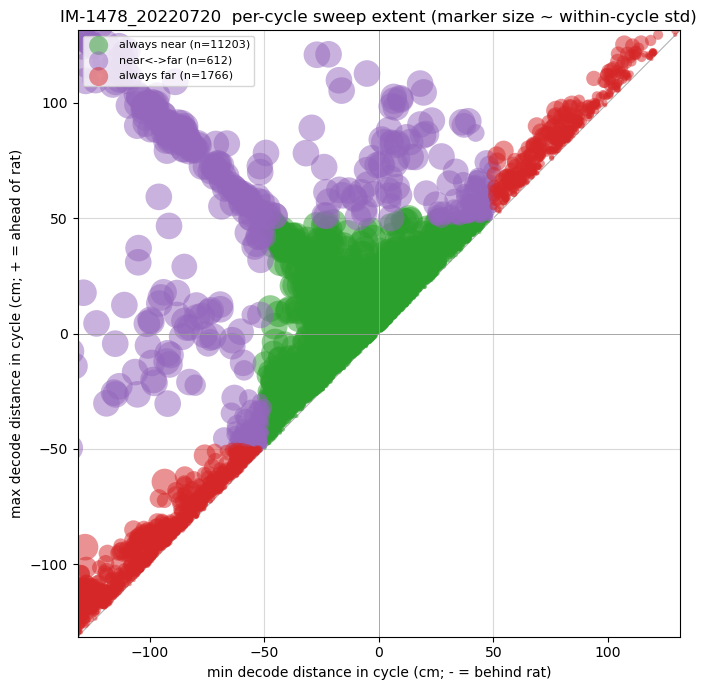

In [8]:
# Scatter each cycle by its decode-distance min (x) vs max (y). Because min <= max, every point
# sits on/above the diagonal; its position shows how near/far the sweep travels, and the marker
# size scales with the within-cycle std. The FAR_THRESH lines mark the near zone: points fully
# beyond them are always-far (nonlocal), points straddling them go near<->far, points inside stay near.
fig, ax = plt.subplots(figsize=(7, 7))
sizes = 8 + 60 * (scored["dist_std"] / scored["dist_std"].median()).clip(0, 6)
for loc, color in LOC_COLORS.items():
    m = (scored["locality"] == loc).values
    ax.scatter(scored.loc[m, "dist_min"], scored.loc[m, "dist_max"],
               s=sizes[m], c=color, alpha=0.5, edgecolors="none",
               label=f"{loc} (n={int(m.sum())})")

lim = np.nanpercentile(np.abs(np.r_[scored["dist_min"].values, scored["dist_max"].values]), 99) * 1.05
ax.plot([-lim, lim], [-lim, lim], color="0.7", lw=0.8, zorder=0)      # min == max (no spread)
for v in (-FAR_THRESH, FAR_THRESH):                                   # near-zone boundary
    ax.axvline(v, color="0.85", lw=0.8, zorder=0)
    ax.axhline(v, color="0.85", lw=0.8, zorder=0)
ax.axhline(0, color="0.6", lw=0.6); ax.axvline(0, color="0.6", lw=0.6)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("min decode distance in cycle (cm; - = behind rat)")
ax.set_ylabel("max decode distance in cycle (cm; + = ahead of rat)")
ax.set_title(f"{session_id}  per-cycle sweep extent (marker size ~ within-cycle std)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
save_fig(fig, f"{session_id}_sweep_min_max_scatter")
plt.show()

saved figures/IM-1478_20220720/IM-1478_20220720_sweep_locality_counts.pdf


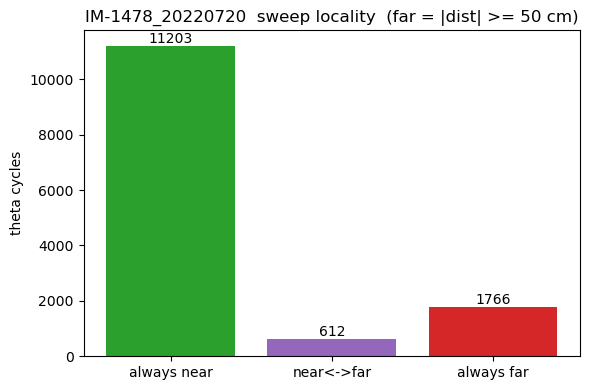

In [9]:
# Bar chart: how many sweeps stay near, cross near<->far, or are always far (fully nonlocal)
counts = scored["locality"].value_counts().reindex(LOC_ORDER).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(LOC_ORDER, counts.values, color=[LOC_COLORS[o] for o in LOC_ORDER])
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set_ylabel("theta cycles")
ax.set_title(f"{session_id}  sweep locality  (far = |dist| >= {FAR_THRESH:g} cm)")
plt.tight_layout()
save_fig(fig, f"{session_id}_sweep_locality_counts")
plt.show()

## Visualize

1. Distribution of per-cycle sweep scores (how forward-biased is theta here?).
2. The canonical sweep signature: mean decode distance vs theta phase (behind early → ahead late),
   shown across two cycles so the sweep reads continuously.

saved figures/IM-1478_20220720/IM-1478_20220720_sweep_score_hist.pdf


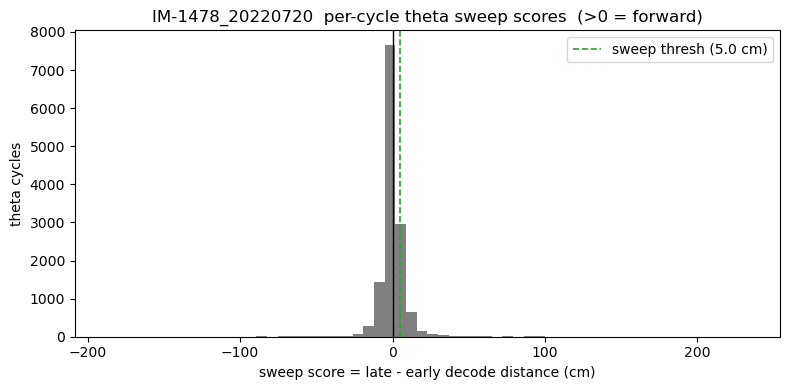

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scored["sweep_score"], bins=60, color="0.5", edgecolor="none")
ax.axvline(0, color="k", lw=1)
ax.axvline(SWEEP_THRESH, color="tab:green", ls="--", lw=1.2, label=f"sweep thresh ({SWEEP_THRESH} cm)")
ax.set_xlabel("sweep score = late - early decode distance (cm)")
ax.set_ylabel("theta cycles")
ax.set_title(f"{session_id}  per-cycle theta sweep scores  (>0 = forward)")
ax.legend()
plt.tight_layout()
save_fig(fig, f"{session_id}_sweep_score_hist")
plt.show()

In [ ]:
# Phase-binned average decode distance = the classic sweep curve.
# Bin every kept sample by theta phase, average decode distance per bin, and tile across two
# cycles (0-720 deg) so the behind->ahead sweep is easy to see.
N_BINS = 24
edges = np.linspace(0, 360, N_BINS + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
which = np.digitize(kept["phase_deg"].values, edges) - 1
which = np.clip(which, 0, N_BINS - 1)

binned = pd.DataFrame({"bin": which, "dist": kept["dist"].values})
g = binned.groupby("bin")["dist"]
mean_d = g.mean().reindex(range(N_BINS))
sem_d = (g.std() / np.sqrt(g.size())).reindex(range(N_BINS))

# Tile to two cycles for a continuous read
x2 = np.r_[centers, centers + 360]
m2 = np.r_[mean_d.values, mean_d.values]
s2 = np.r_[sem_d.values, sem_d.values]

fig, ax = plt.subplots(figsize=(11, 4))
ax.axhline(0, color="0.7", lw=0.8)                                   # rat's own position
for c in (180, 360, 540):
    ax.axvline(c, color="0.85", lw=0.8)                             # trough / peak gridlines
ax.fill_between(x2, m2 - s2, m2 + s2, color="tab:purple", alpha=0.25, lw=0)
ax.plot(x2, m2, color="tab:purple", lw=1.8)
# shade the early half of each cycle so it lines up with the big time-series plot's convention
for base in (0, 360):
    ax.axvspan(base + EARLY_BAND[0], base + EARLY_BAND[1], color="tab:blue", alpha=0.06, lw=0)
    ax.axvspan(base + LATE_BAND[0], base + LATE_BAND[1], color="tab:orange", alpha=0.06, lw=0)
ax.set_xlim(0, 720)
ax.set_xticks([0, 180, 360, 540, 720])
ax.set_xlabel("theta phase (deg)  [0/360/720 = peak, 180/540 = trough]")
ax.set_ylabel("mean decode distance\n(cm; + = ahead of rat)")
ax.set_title(f"{session_id}  theta sweep: decode distance vs phase  (n={int(kept['keep'].count())} samples)")
plt.tight_layout()
save_fig(fig, f"{session_id}_sweep_distance_vs_phase")
plt.show()